# Two QED classics with feynsage

Peskin and Schroeder compute two one-loop effects of QED by hand. Here feynsage does them step by step, and every
number is checked against the book and against experiment.

1. **Vacuum polarisation** (Peskin section 7.5): the photon self energy $\Pi(q^2)$, the Ward identity, and the
   running of $\alpha$ up to the $Z$ mass.
2. **The anomalous magnetic moment of the electron** (Peskin section 6.3): $F_2(0) = \alpha/2\pi$, with $\mathcal U$ and
   $\mathcal F$ read off the vertex graph, the Dirac algebra done by FORM and every integral done exactly.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.getcwd())
from feynsage import *
from feynsage.plotting import set_theme, quick_plot
import mpmath
set_theme()
%matplotlib inline

## 1. Vacuum polarisation

The electron loop in the photon propagator is
$$ i\Pi^{\mu\nu}(q) = -(-ie)^2 \int \frac{d^4\ell}{(2\pi)^4}\,
   \mathrm{Tr}\Big[\gamma^\mu \frac{i(\not\ell + m)}{\ell^2 - m^2}\,\gamma^\nu \frac{i(\not\ell + \not q + m)}{(\ell + q)^2 - m^2}\Big] $$
(the first minus sign is the fermion loop). FORM does the trace in $d$ dimensions and `form.to_loop` turns it into
a numerator that `loop()` understands:

In [2]:
T = form.dirac_trace(['mu', 'l + m', 'nu', 'l + q + m'], vectors=['l', 'q'], dim='D')
num = form.to_loop(T).replace('D', 'd')
print("trace:", T)
res = loop(num, ["l", "m"], ["l + q", "m"], kin={"q^2": "s"})
res

trace: 4*m^2*g(mu, nu) + 8*comp(l, mu)*comp(l, nu) + 4*comp(l, nu)*comp(q, mu) + 4*comp(l, mu)*comp(q, nu) - 4*dot(l, l)*g(mu, nu) - 4*dot(l, q)*g(mu, nu)


g^{mu nu} :  -8/3*m^2*(1/eps + log(mu^2/m^2) + 1) + 8/3*m^2 + 4/3*(2*m^2 + s)*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2) - 4/9*s
q^mu q^nu :  8/3*m^2*(1/eps + log(mu^2/m^2) + 1)/s - 8/9*m^2/s - 4/3*(2*m^2 + s)*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2)/s - 4/9*(4*m^2 - s)/s

With $\int d^4\ell/(2\pi)^4 = \frac{i}{16\pi^2}\times$(the `loop` normalisation) the prefactors give
$\Pi^{\mu\nu} = -\frac{e^2}{16\pi^2} L^{\mu\nu}$, where $L^{\mu\nu}$ is the output above.

**The Ward identity.** Gauge invariance demands $q_\mu \Pi^{\mu\nu} = 0$, that is
$\Pi^{\mu\nu} = (q^2 g^{\mu\nu} - q^\mu q^\nu)\,\Pi(q^2)$. So the coefficient of $g^{\mu\nu}$ must be $-q^2$ times the
coefficient of $q^\mu q^\nu$. This is an exact identity between the two formulas, including the $1/\epsilon$ poles:

In [3]:
s = var('s')
Cg, Cqq = res["g^{mu nu}"], res["q^mu q^nu"]
print("C_g + q^2 C_qq =", (Cg + s * Cqq).expand())

C_g + q^2 C_qq = 0


So $\Pi(q^2) = \frac{\alpha}{4\pi} C_{qq}(q^2)$ with $e^2 = 4\pi\alpha$. Its $1/\epsilon$ pole is removed by charge
renormalisation, which leaves $\hat\Pi(q^2) = \Pi(q^2) - \Pi(0)$. $\Pi(0)$ comes from the same reduction at $q^2 = 0$
(feynsage handles the light-like case exactly). Peskin's eq. (7.91) gives the same thing as a Feynman-parameter integral,
$$ \hat\Pi(q^2) = -\frac{2\alpha}{\pi}\int_0^1 dx\; x(1-x)\,\log\frac{m^2}{m^2 - x(1-x)q^2 - i0} .$$
Compare the two, below and above the pair threshold $q^2 = 4m^2$ (units $m = 1$, in units of $\alpha/4\pi$):

In [4]:
res0 = loop(num, ["l", "m"], ["l + q", "m"], kin={"q^2": 0})
Cqq0 = res0["q^mu q^nu"]
m_ = var('m')

def Pi_hat_ours(sv, mv=1):
    return complex(finite_part(Cqq, 1).subs({s: sv, m_: mv}).n() - finite_part(Cqq0, 1).subs({m_: mv}).n())

# Peskin (7.91) with mpmath; see tests/peskin_ref.py (plain Python, no Sage preparsing)
sys.path.insert(0, os.path.join(os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.getcwd(), 'tests'))
from peskin_ref import pi_hat as Pi_hat_peskin

for sv in (-7, -1, 1, 3, 5, 12, 40):
    a, b = Pi_hat_ours(sv), Pi_hat_peskin(sv)
    print("q^2 = %4s   feynsage %-44s Peskin (7.91) %-44s" % (sv, "%.12f %+.12fi" % (a.real, a.imag), "%.12f %+.12fi" % (b.real, b.imag)))

q^2 =   -7   feynsage 1.147869134305 -0.000000000000i              Peskin (7.91) 1.147869134305 -0.000000000000i             
q^2 =   -1   feynsage 0.241718171351 +0.000000000000i              Peskin (7.91) 0.241718171351 -0.000000000000i             
q^2 =    1   feynsage -0.300358098619 -0.000000000000i             Peskin (7.91) -0.300358098619 -0.000000000000i            
q^2 =    3   feynsage -1.312889830764 -0.000000000000i             Peskin (7.91) -1.312889830764 -0.000000000000i            


q^2 =    5   feynsage -2.485458865756 -2.622597499589i             Peskin (7.91) -2.485458865756 -2.622597499589i            


q^2 =   12   feynsage 0.244964075878 -3.990155027170i              Peskin (7.91) 0.244964075878 -3.990155027170i             
q^2 =   40   feynsage 2.474807840408 -4.172527071634i              Peskin (7.91) 2.474807840408 -4.172527071634i             


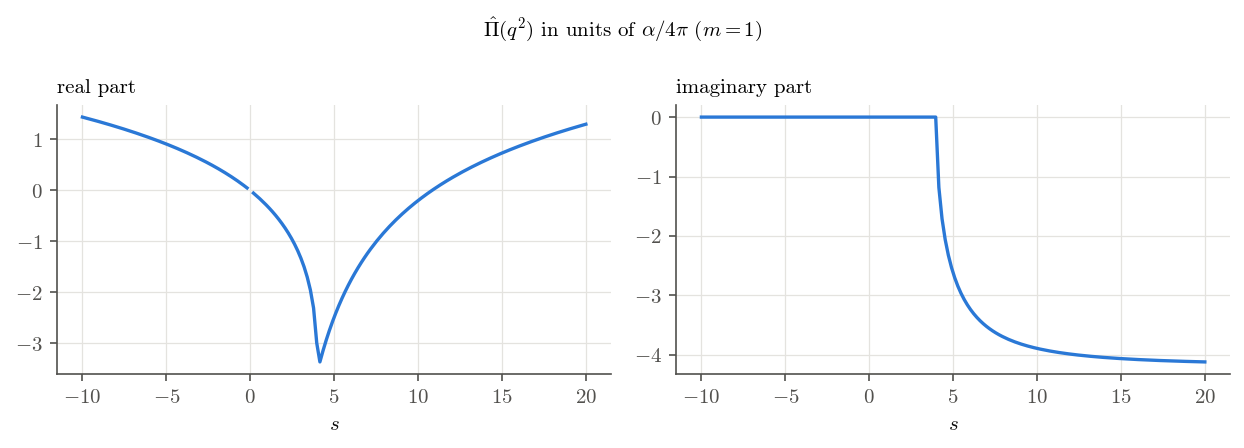

In [5]:
quick_plot(finite_part(Cqq, 1).subs({m_: 1}) - finite_part(Cqq0, 1).subs({m_: 1}), (s, -10, 20),
           title=r"$\hat\Pi(q^2)$ in units of $\alpha/4\pi$ ($m = 1$)");

The imaginary part switches on at $q^2 = 4m^2$: above threshold the virtual photon can make a real
electron-positron pair (the optical theorem of the notes).

**Running of $\alpha$.** With $\alpha_{\rm eff}(q^2) = \alpha/(1 - \hat\Pi(q^2))$, the three charged leptons change
$\alpha$ between $q^2 = 0$ and $q^2 = M_Z^2$ by $\Delta\alpha = \sum_\ell \mathrm{Re}\,\hat\Pi_\ell(M_Z^2)$:

In [6]:
alpha = 1 / 137.035999084
MZ = 91187.6                                            # MeV
leptons = {"e": 0.51099895, "mu": 105.6583755, "tau": 1776.86}
for name, ml in leptons.items():
    print("%-4s %.6f" % (name, alpha / (4 * pi.n()) * Pi_hat_ours(MZ ** 2, ml).real))
dalpha = sum(alpha / (4 * pi.n()) * Pi_hat_ours(MZ ** 2, ml).real for ml in leptons.values())
print("Delta alpha_leptons(M_Z^2) = %.6f   ->  1/alpha from 137.036 to %.2f" % (dalpha, (1 - dalpha) / alpha))

e    0.017435
mu   0.009178
tau  0.004806
Delta alpha_leptons(M_Z^2) = 0.031419   ->  1/alpha from 137.036 to 132.73


The one-loop value $0.031419$ is what the literature quotes for the one-loop leptonic part; two and three loops
add about $0.25\%$, which gives $0.031498$ (M. Steinhauser, Phys. Lett. B 429 (1998) 158). The measured
$1/\alpha(M_Z) \approx 128$ also contains the quark loops, which are not computed here.

## 2. The anomalous magnetic moment: $F_2(0) = \alpha/2\pi$

The vertex correction has a photon line and two electron lines. Take the graph: photon between A and B, electron lines
C-A (momentum $p + \ell$) and B-C ($p' + \ell$), with $p^2 = p'^2 = m^2$ and $q^2 = (p' - p)^2 = Q^2$.
$\mathcal U$ and $\mathcal F$ follow from the spanning trees and 2-forests:

U = x1 + x2 + x3    F = m^2*x2^2 + (2*m^2 - Q2)*x2*x3 + m^2*x3^2
Delta = F/U on the simplex: m^2*x2^2 + 2*m^2*x2*x3 + m^2*x3^2 - Q2*x2*x3


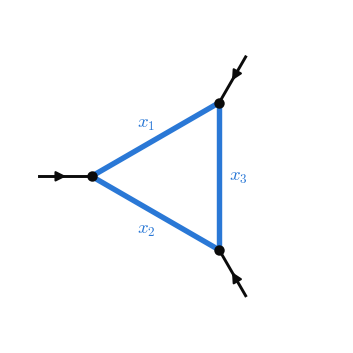

In [7]:
Q2, m = var('Q2 m')
vert = graph("A-B, C-A:m, B-C:m", {"A": "p", "B": "-pp", "C": "pp - p"},
             kin={"p^2": "m^2", "pp^2": "m^2", "p.pp": "m^2 - Q2/2"})
U, F = vert.U(), vert.F()
print("U =", U, "   F =", F)
vert.plot(momenta=False);
x2s, x3s = SR.var('x2'), SR.var('x3')
Delta = SR(str(F)).subs({SR.var('x1'): 1 - x2s - x3s}).expand()
print("Delta = F/U on the simplex:", Delta)

This is exactly $\Delta$ of Peskin (6.47) with $z = x_1$ (the photon line). The shift that brings the denominator to
$(k^2 - \Delta)^3$ is $\ell = k - x_2 p - x_3 p'$.

**Projecting out $F_2$.** Between on-shell spinors, $\Gamma^\mu = \gamma^\mu F_1 + \frac{i\sigma^{\mu\nu}q_\nu}{2m}F_2$ can
be written (Gordon identity) as $A\,\gamma^\mu + B\,(p + p')^\mu/2m$ with $F_2 = -B$. Tracing with $(\not p' + m)\ldots(\not p + m)$
and $\gamma_\mu$ or $(p+p')_\mu$ gives two numbers, from which $A$ and $B$ follow. FORM computes all traces in $d$ dimensions:

In [8]:
vec = ['p', 'pp', 'k']
Dd, K2, Kp, Kpp = SR.var('D'), SR.var('K2'), SR.var('Kp'), SR.var('Kpp')
dot_ = function('dot')
table = {('p','p'): m^2, ('pp','pp'): m^2, ('p','pp'): m^2 - Q2/2, ('k','k'): K2, ('k','p'): Kp, ('k','pp'): Kpp}

def tr(factors):
    e = form.dirac_trace(factors, vectors=vec, dim='D')
    return e.substitute_function(dot_, lambda a, b: table.get((str(a), str(b)), table.get((str(b), str(a))))).expand()

M = matrix(SR, [[tr(['pp + m', 'mu', 'p + m', 'mu']), tr(['pp + m', 'p + pp', 'p + m']) / (2*m)],
                [tr(['pp + m', 'p + pp', 'p + m']), tr(['pp + m', 'p + m']) * (4*m^2 - Q2) / (2*m)]])
print("projector matrix, determinant:", M.det().factor())
lp = 'k - x2*p - x3*pp'
NG = tr(['pp + m', 'nu', 'pp + %s + m' % lp, 'mu', 'p + %s + m' % lp, 'nu', 'p + m', 'mu'])
NV = tr(['pp + m', 'nu', 'pp + %s + m' % lp, 'p + pp', 'p + %s + m' % lp, 'nu', 'p + m'])

projector matrix, determinant: 2*(4*m^2 - Q2)^2*(D - 2)*Q2/m


The determinant vanishes at $Q^2 = 0$: at zero momentum transfer $p = p'$ and the two structures cannot be told apart.
So $F_2(0)$ is taken as the limit $Q^2 \to 0$ at the end.

**The $k$ integral.** Odd powers of $k$ vanish and $k^\mu k^\nu \to g^{\mu\nu} k^2/d$. Then
$\int \frac{d^dk}{i\pi^{d/2}} \frac{(k^2)^j}{(k^2 - \Delta)^3} = (-1)^{3+j}\frac{\Gamma(j + d/2)\Gamma(3 - j - d/2)}{\Gamma(d/2)\Gamma(3)}\Delta^{d/2+j-3}$ exactly:

In [9]:
def symint(e):
    out = 0
    for t in (e.operands() if 'add' in str(e.operator()) else [e]):
        a, b = t.degree(Kp), t.degree(Kpp)
        c = t.subs({Kp: 1, Kpp: 1})
        if a + b == 0:                  out += c
        elif (a, b) in ((2, 0), (0, 2)): out += c * m^2 * K2 / Dd
        elif (a, b) == (1, 1):          out += c * (m^2 - Q2/2) * K2 / Dd
    return out

AB = M.solve_right(vector(SR, [symint(NG), symint(NV)]))
F2num = (-AB[1]).expand()
eps_, Dl = SR.var('eps_'), SR.var('Dl')
def kint(j):
    d = 4 - 2*eps_
    return (-1)^(3 + j) * gamma(j + d/2) * gamma(3 - j - d/2) / (gamma(d/2) * gamma(3)) * Dl^(d/2 + j - 3)
integrand = (F2num.coefficient(K2, 0) * kint(0) + F2num.coefficient(K2, 1) * kint(1)).subs({Dd: 4 - 2*eps_})
ser = integrand.series(eps_, 1)
print("UV pole of F2:", ser.coefficient(eps_, -1).simplify_full())
fin0 = ser.coefficient(eps_, 0).subs({Dl: Delta}).series(Q2, 1).truncate().coefficient(Q2, 0).simplify_full()
print("F2 integrand at Q^2 = 0:", fin0)

UV pole of F2: 0
F2 integrand at Q^2 = 0: -2*(x2 + x3 - 1)/(x2 + x3)


No UV pole, as it must be for a quantity that has no counterterm. With $z = 1 - x_2 - x_3$ the integrand is
$2z/(1 - z)$, exactly the integrand of Peskin (6.56) at $q^2 = 0$. The Feynman-parameter integral and the prefactor
$e^2/16\pi^2$ finish the job:

In [10]:
assume(x2s > 0, x2s < 1, m > 0)
J = 2 * integrate(integrate(fin0, x3s, 0, 1 - x2s), x2s, 0, 1)
F2 = (J / (16*pi^2) * 4*pi).simplify_full()
print("F2(0) =", F2, "* alpha")
a_exp = 0.00115965218059
print("alpha/(2 pi) = %.10f,  measured a_e = %.14f (X. Fan et al., PRL 130 (2023) 071801)" % (alpha / (2*pi.n()), a_exp))
print("the one-loop term is %.2f%% above the measurement; two loops (-0.328 (alpha/pi)^2) bring it within 0.001%%"
      % (100 * (alpha / (2*pi.n()) / a_exp - 1)))

F2(0) = 1/2/pi * alpha
alpha/(2 pi) = 0.0011614097,  measured a_e = 0.00115965218059 (X. Fan et al., PRL 130 (2023) 071801)
the one-loop term is 0.15% above the measurement; two loops (-0.328 (alpha/pi)^2) bring it within 0.001%


Schwinger's $\alpha/2\pi$ from 1948, reproduced from the graph with exact algebra. It is $0.15\%$ above the measured
value. The next term, $-0.328\,(\alpha/\pi)^2$, closes that gap to about one part in $10^5$.